# Import Trained Data

In [1]:
import pickle
with open('customer.pkl', 'rb') as f:
    X_customer_balanced, Y_customer_balanced = pickle.load(f)

# Import Test Data

In [2]:
import pandas as pd
import numpy as np

# Imports
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Import Data
test_data = pd.read_csv("C:\\Users\\bruno\\projeto_churn_predict\\projeto_churn_predict\\files\\test_data.csv")

In [5]:
# Fill null values with mean
test_data['NetworkScore'].fillna(test_data['NetworkScore'].mean(), inplace = True)
test_data['Age'].fillna(test_data['Age'].mean(), inplace = True)
test_data['EstimatedMonthlyUsage'].fillna(test_data['EstimatedMonthlyUsage'].mean(), inplace = True)
test_data['IsActiveMember'].fillna(test_data['IsActiveMember'].mean(), inplace = True)

In [6]:
# Drop null lines
test_data.dropna(subset=['IsActiveMember'], inplace=True)

In [7]:
# Drop unwanted columns
#test_data = test_data.drop(['HasInternetService'], axis=1)

In [8]:
# Select the values
X_test = test_data.iloc[:, 1:12].values

In [9]:
# Imports
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [10]:
# Instance
label_encoder_surname = LabelEncoder()
label_encoder_gender = LabelEncoder()
label_encoder_region = LabelEncoder()

In [11]:
if isinstance(X_test, np.ndarray):
    X_test = pd.DataFrame(X_test) 

X_test.iloc[:, 0] = label_encoder_surname.fit_transform(X_test.iloc[:, 0])
X_test.iloc[:, 2] = label_encoder_region.fit_transform(X_test.iloc[:, 2])
X_test.iloc[:, 3] = label_encoder_gender.fit_transform(X_test.iloc[:, 3])

In [12]:
scaler_test = StandardScaler()
X_test = scaler_test.fit_transform(X_test)
print(
    X_test
)

[[ 1.13023890e+00 -6.84726076e-01  4.17406800e-01 ...  1.01117353e+00
  -1.01700270e+00  2.09265462e-02]
 [ 1.44594258e+00 -5.76792828e-01 -1.35422335e+00 ...  1.01117353e+00
  -1.01700270e+00  4.47880389e-16]
 [ 1.37578621e+00  1.25807239e+00 -1.35422335e+00 ... -9.88949937e-01
   1.03668663e+00 -8.89947806e-01]
 ...
 [ 1.13023890e+00  5.02539654e-01 -1.35422335e+00 ...  1.01117353e+00
   1.03668663e+00 -1.81936576e-02]
 [-3.12977904e-01  1.15013914e+00  1.30322187e+00 ...  1.01117353e+00
   1.03668663e+00  1.49516335e+00]
 [-9.09307072e-01  1.61784989e+00  4.17406800e-01 ... -9.88949937e-01
  -1.01700270e+00  4.47880389e-16]]


# Predict - Random Forest

In [13]:
X_customer_balanced.shape, Y_customer_balanced.shape

((4136, 11), (4136,))

In [14]:
from sklearn.ensemble import RandomForestClassifier

In [15]:
model_forest = RandomForestClassifier(n_estimators=80, criterion='entropy', random_state=42)
model_forest.fit(X_customer_balanced, Y_customer_balanced)

,n_estimators,80
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
previsoes = model_forest.predict(X_test)

In [17]:
previsoes

array([1, 1, 0, ..., 1, 1, 1], shape=(1980,))

In [18]:
# Create a DataFrame for the predictions
test_data['Exited'] = previsoes

In [19]:
# Output the first few rows of the predictions
print(test_data[['CustomerID', 'Exited']])

      CustomerID  Exited
0           5081       1
1           3273       1
2           3565       0
3           2735       1
4           2163       1
...          ...     ...
1975        2588       1
1976        3324       0
1977        1901       1
1978        4629       1
1979         732       1

[1980 rows x 2 columns]


In [20]:
# Export classified IDs and predictions to CSV
test_data[['CustomerID', 'Exited']].to_csv('classified_customers.csv', index=False)

In [21]:
# Statistic views for prediction results

# 1. Count of customers who exited vs. stayed
exit_counts = test_data['Exited'].value_counts()
print("Exited value counts:\n", exit_counts)

# 2. Percentage of customers who exited
exit_percentage = test_data['Exited'].mean() * 100
print(f"\nPercentage of customers who exited: {exit_percentage:.2f}%")

# 3. Group by Region and show exit rates
region_exit_rate = test_data.groupby('Region')['Exited'].mean().sort_values(ascending=False)
print("\nExit rate by Region:\n", region_exit_rate)

# 4. Group by Gender and show exit rates
gender_exit_rate = test_data.groupby('Gender')['Exited'].mean().sort_values(ascending=False)
print("\nExit rate by Gender:\n", gender_exit_rate)

Exited value counts:
 Exited
1    1296
0     684
Name: count, dtype: int64

Percentage of customers who exited: 65.45%

Exit rate by Region:
 Region
East     0.668712
South    0.654959
West     0.650190
North    0.644491
Name: Exited, dtype: float64

Exit rate by Gender:
 Gender
Female    0.957547
Male      0.616519
Other     0.403904
Name: Exited, dtype: float64


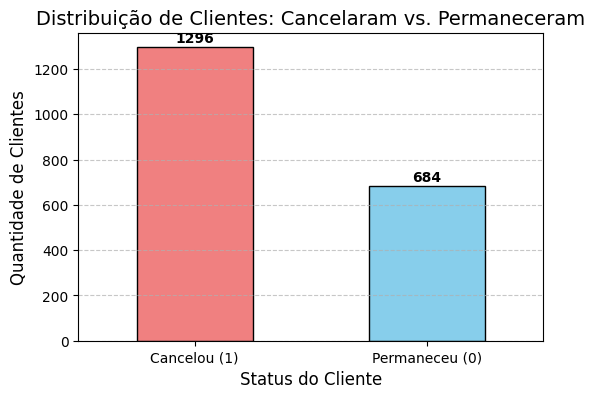

In [22]:
import matplotlib.pyplot as plt

# Contagem de clientes que cancelaram vs. permaneceram
exit_counts = test_data['Exited'].value_counts()

plt.figure(figsize=(6,4))
exit_counts.plot(kind='bar', color=['lightcoral', 'skyblue'], edgecolor='black')

plt.title('Distribuição de Clientes: Cancelaram vs. Permaneceram', fontsize=14)
plt.xlabel('Status do Cliente', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)
plt.xticks(ticks=[1,0], labels=['Permaneceu (0)', 'Cancelou (1)'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adiciona rótulos com os valores
for i, v in enumerate(exit_counts):
    plt.text(i, v + 20, str(v), ha='center', fontsize=10, fontweight='bold')

plt.show()

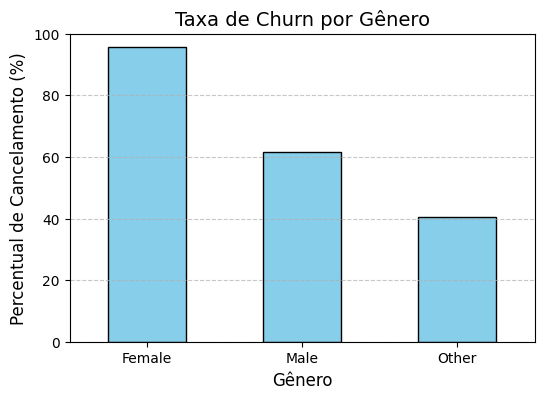

In [27]:
import matplotlib.pyplot as plt

# Taxa de churn por gênero
gender_exit_rate = test_data.groupby('Gender')['Exited'].mean() * 100

plt.figure(figsize=(6,4))
gender_exit_rate.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Taxa de Churn por Gênero', fontsize=14)
plt.ylabel('Percentual de Cancelamento (%)', fontsize=12)
plt.xlabel('Gênero', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

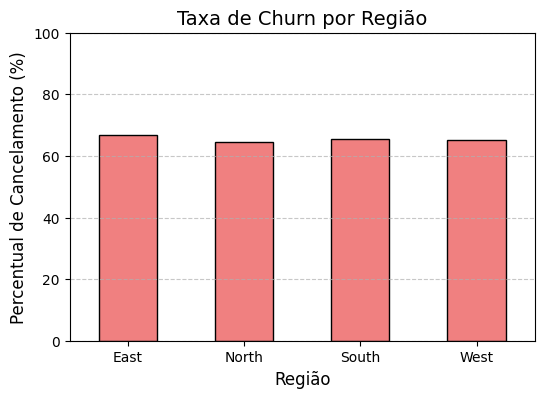

In [24]:
# Taxa de churn por região
region_exit_rate = test_data.groupby('Region')['Exited'].mean() * 100

plt.figure(figsize=(6,4))
region_exit_rate.plot(kind='bar', color='lightcoral', edgecolor='black')

plt.title('Taxa de Churn por Região', fontsize=14)
plt.ylabel('Percentual de Cancelamento (%)', fontsize=12)
plt.xlabel('Região', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [25]:
from sklearn.metrics import confusion_matrix

# Assuming the true labels are available in test_data['Exited']
# and predictions are in previsoes

cm = confusion_matrix(test_data['Exited'], previsoes)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 684    0]
 [   0 1296]]


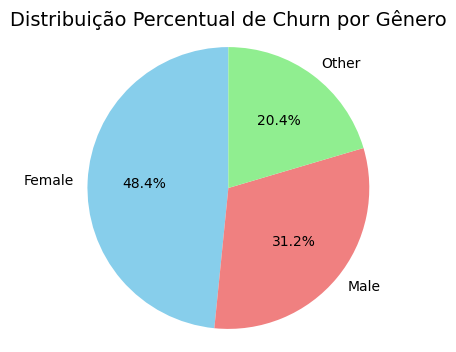

In [30]:
import matplotlib.pyplot as plt

# Taxa de churn por gênero (já calculada em gender_exit_rate)
plt.figure(figsize=(4, 4))
plt.pie(gender_exit_rate, labels=gender_exit_rate.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Distribuição Percentual de Churn por Gênero', fontsize=14)
plt.axis('equal')  # Deixa o gráfico circular
plt.show()

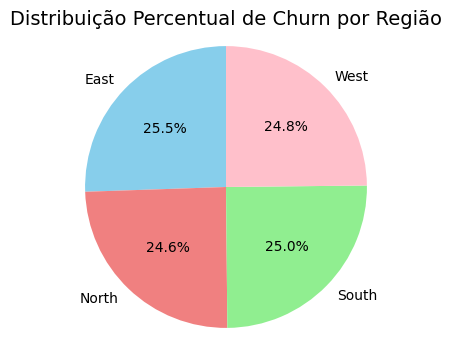

In [31]:
import matplotlib.pyplot as plt

# Taxa de churn por região (já calculada em region_exit_rate)
plt.figure(figsize=(4, 4))
plt.pie(region_exit_rate, labels=region_exit_rate.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral', 'lightgreen', 'pink'])
plt.title('Distribuição Percentual de Churn por Região', fontsize=14)
plt.axis('equal')  # Deixa o gráfico circular
plt.show()